# Baseline Model

## Table of Contents
1. [Model Choice](#model-choice)
2. [Feature Selection](#feature-selection)
3. [Implementation](#implementation)
4. [Evaluation](#evaluation)


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim


## Model Choice

[Explain why you've chosen a particular model as the baseline. This could be a simple statistical model or a basic machine learning model. Justify your choice.]


Simple Neural Network with Linear Layers and ReLu. Close to a potential final classification layer in a future model.

## Feature Selection

[Indicate which features from the dataset you will be using for the baseline model, and justify your selection.]


In [16]:
# Load the dataset
x_df = pd.read_csv('../data/X_train.csv')
y_df = pd.read_csv('../data/Y_train.csv')

C:\Users\tomhi\AppData\Local\Temp\ipykernel_26996\4008261101.py:2: DtypeWarning: Columns (0: item21, 1: item22, 2: item23, 3: item24, 4: make21, 5: make22, 6: make23, 7: make24, 8: model21, 9: model22, 10: model23, 11: model24, 12: goods_code1, 13: goods_code8, 14: goods_code9, 15: goods_code10, 16: goods_code11, 17: goods_code12, 18: goods_code13, 19: goods_code14, 20: goods_code15, 21: goods_code16, 22: goods_code17, 23: goods_code18, 24: goods_code19, 25: goods_code20, 26: goods_code21, 27: goods_code22, 28: goods_code23, 29: goods_code24) have mixed types. Specify dtype option on import or set low_memory=False.
  x_df = pd.read_csv('../data/X_train.csv')


In [ ]:
# Add aggregate features 
price_cols = [f'cash_price{i}' for i in range(1, 25)]
prod_purchas_col = [f'Nbr_of_prod_purchas{i}' for i in range(1, 25)]

x_df['total_basket_value'] = x_df[price_cols].sum(axis=1, skipna=True)
x_df['num_of_items'] = x_df[prod_purchas_col].sum(axis=1, skipna=True)
x_df['max_item_price'] = x_df[price_cols].max(axis=1, skipna=True)
x_df['avg_item_price'] = x_df['total_basket_value'] / x_df['num_of_items']

item_cols = [f'item{i}' for i in range(1, 25)]
x_df['computer_count'] = (x_df[item_cols] == 'COMPUTERS').sum(axis=1) / x_df['num_of_items'] # computers are the most common fraud item



feature_columns = ['num_of_items', 'total_basket_value', 'max_item_price', 'avg_item_price', 'computer_count']
num_features = x_df[feature_columns].copy()

num_features.head()

,num_of_items,total_basket_value,max_item_price,avg_item_price,computer_count
0,1.0,889.0,889.0,889.0,1.0
1,1.0,409.0,409.0,409.0,0.0
2,1.0,1399.0,1399.0,1399.0,0.0
3,2.0,808.0,689.0,404.0,0.5
4,1.0,1199.0,1199.0,1199.0,0.0


In [ ]:
from sklearn.preprocessing import StandardScaler

x_data = torch.tensor(num_features.values, dtype=torch.float32)

y_fraud_flag = y_df[['fraud_flag']].copy()
y_data = torch.tensor(y_fraud_flag.values, dtype=torch.float32)

print(x_data.shape)
print(y_data.shape)

torch.Size([92790, 5])
torch.Size([92790, 1])


In [19]:
# Split data in training, validation and test set - 60% train, 20% val, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(x_data, y_data, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

### Dataset/Dataloader

In [20]:
from torch.utils.data import Dataset

class FraudDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            self.X[idx],
            self.y[idx]
        )

In [21]:
scaler = StandardScaler()

def preprocess(x, fit=False):
    global scaler

    if fit:
        x_scaled = scaler.fit_transform(x)
    else:
        x_scaled = scaler.transform(x)

    return torch.tensor(x_scaled, dtype=torch.float32)

# Preprocess data
X_train = preprocess(X_train, fit=True)
X_val = preprocess(X_val)
X_test = preprocess(X_test)

In [22]:
# DataSet
train_dataset = FraudDataset(X_train, y_train)
val_dataset = FraudDataset(X_val, y_val)
test_dataset = FraudDataset(X_test, y_test)

In [23]:
# Data Loaders
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Implementation

[Implement your baseline model here.]



In [24]:
# Initialize the baseline model
N_INPUT_FEATURES = len(feature_columns)
LEARNING_RATE = 0.001
NUM_EPOCHS = 50
DROPOUT_RATE = 0.1

model = nn.Sequential(
    nn.Linear(N_INPUT_FEATURES, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Dropout(DROPOUT_RATE),
    nn.Linear(8, 1),
)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

num_pos = y_train[:, 0].sum()
num_neg = len(y_train) - num_pos
pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32)

loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(model)


Sequential(
  (0): Linear(in_features=5, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Dropout(p=0.1, inplace=False)
  (5): Linear(in_features=8, out_features=1, bias=True)
)


In [25]:
# Train and validate the baseline model
from sklearn.metrics import average_precision_score

train_losses = []
val_losses = []
pr_aucs = []

for epoch in range(NUM_EPOCHS):
    # --- TRAINING ---
    model.train()
    train_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X).squeeze()
        loss = loss_function(outputs, batch_y.float().squeeze())
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_X.size(0)

    avg_train_loss = train_loss / len(train_loader.dataset)

    # --- VALIDATION ---
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X).squeeze()
            loss = loss_function(outputs, batch_y.float().squeeze())
            val_loss += loss.item() * batch_X.size(0)

            # convert logits to probabilities
            probs = torch.sigmoid(outputs)
            all_preds.extend(probs.numpy())
            all_labels.extend(batch_y.numpy())

    avg_val_loss = val_loss / len(val_loader.dataset)
    pr_auc = average_precision_score(all_labels, all_preds)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    pr_aucs.append(pr_auc)

    print(f'Epoch {epoch+1}/{NUM_EPOCHS} | '
          f'Train Loss: {avg_train_loss:.4f} | '
          f'Val Loss: {avg_val_loss:.4f} | '
          f'VAL PR-AUC: {pr_auc:.4f}')

Epoch 1/50 | Train Loss: 1.3524 | Val Loss: 1.3223 | VAL PR-AUC: 0.0289
Epoch 2/50 | Train Loss: 1.2853 | Val Loss: 1.2827 | VAL PR-AUC: 0.0343
Epoch 3/50 | Train Loss: 1.2478 | Val Loss: 1.2551 | VAL PR-AUC: 0.0332
Epoch 4/50 | Train Loss: 1.2304 | Val Loss: 1.2445 | VAL PR-AUC: 0.0346
Epoch 5/50 | Train Loss: 1.2148 | Val Loss: 1.2353 | VAL PR-AUC: 0.0344
Epoch 6/50 | Train Loss: 1.2108 | Val Loss: 1.2217 | VAL PR-AUC: 0.0334
Epoch 7/50 | Train Loss: 1.2028 | Val Loss: 1.2174 | VAL PR-AUC: 0.0383
Epoch 8/50 | Train Loss: 1.1914 | Val Loss: 1.2166 | VAL PR-AUC: 0.0370
Epoch 9/50 | Train Loss: 1.1900 | Val Loss: 1.2103 | VAL PR-AUC: 0.0368
Epoch 10/50 | Train Loss: 1.1832 | Val Loss: 1.2089 | VAL PR-AUC: 0.0374
Epoch 11/50 | Train Loss: 1.1831 | Val Loss: 1.2040 | VAL PR-AUC: 0.0364
Epoch 12/50 | Train Loss: 1.1824 | Val Loss: 1.2012 | VAL PR-AUC: 0.0360
Epoch 13/50 | Train Loss: 1.1856 | Val Loss: 1.2013 | VAL PR-AUC: 0.0362
Epoch 14/50 | Train Loss: 1.1772 | Val Loss: 1.2006 | VAL PR

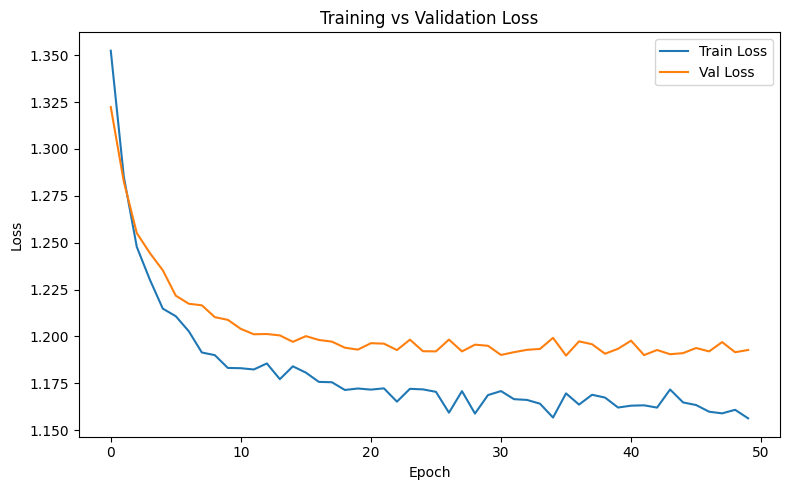

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

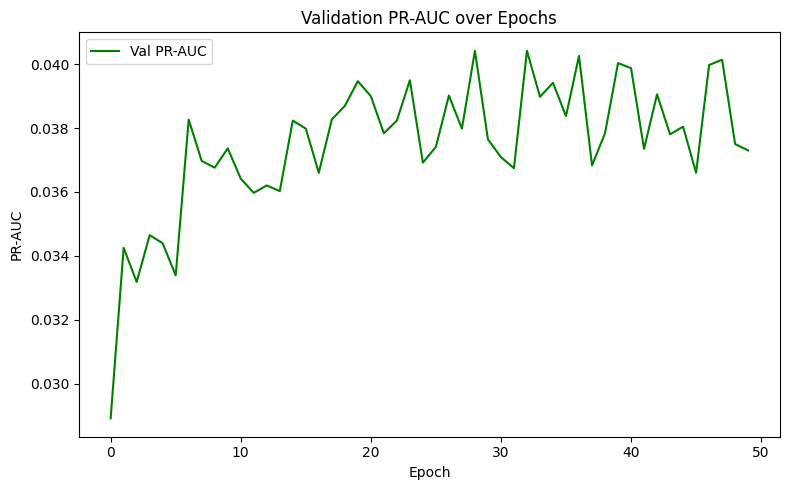

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(pr_aucs, label='Val PR-AUC', color='green')
plt.xlabel('Epoch')
plt.ylabel('PR-AUC')
plt.title('Validation PR-AUC over Epochs')
plt.legend()
plt.tight_layout()
plt.show()

## Evaluation

[Clearly state what metrics you will use to evaluate the model's performance. These metrics will serve as a starting point for evaluating more complex models later on.]



**Metric:** PR-AUC as defined in the project's description - supposed to capture how well the model handles the class imbalance


In [28]:
# Evaluate the baseline model on test set

model.eval()
test_preds = []
test_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X).squeeze()
        probs = torch.sigmoid(outputs)
        test_preds.extend(probs.numpy())
        test_labels.extend(batch_y.numpy())

test_pr_auc = average_precision_score(test_labels, test_preds)
print(f'++ Test Set PR-AUC: {test_pr_auc:.4f} ++')


++ Test Set PR-AUC: 0.0420 ++
